## Phase 1: Exploratory Data Analysis & Data Preprocessing

### Step 1: Setting up the Workspace & Loading Data
Alright, first things first! Let's get the environment set up. I'm importing the standard data science stack here—`pandas` and `numpy` for data manipulation, plus `matplotlib` and `seaborn` so we can make some nice visuals later on. I'm also grabbing the specific `scikit-learn` modules I know I'll need for splitting the data, handling missing values, and scaling our features.

Once the tools are loaded, I'll pull in the `Health_Risk_Tiers_v2.csv` dataset and take a quick peek at the first few rows just to make sure everything loaded correctly.

In [9]:
# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Set plotting style
sns.set_theme(style="whitegrid")

# File path 
file_path = '/kaggle/input/datasets/vsnihal/t4-ml-indivitual-final-project-dataset/Health_Risk_Tiers_v2.xlsx' 

# --- DATA LOADER ---
print("Attempting to load dataset...")

try:
    # Attempt 1: Maybe it is actually an Excel file
    df = pd.read_excel(file_path)
    print("Success! Loaded as an Excel file (.xlsx)")

except Exception:
    try:
        # Attempt 2: Standard CSV, but we tell it to explicitly look for commas 
        # and skip any corrupted rows without crashing
        df = pd.read_csv(file_path, encoding='utf-8', sep=',', on_bad_lines='skip')
        print("Success! Loaded as UTF-8 CSV.")
        
    except UnicodeDecodeError:
        try:
            # Attempt 3: The Windows/Excel text encoding fix (cp1252 is safer than latin-1)
            df = pd.read_csv(file_path, encoding='cp1252', sep=',', on_bad_lines='skip')
            print("Success! Loaded as Windows-1252 encoded CSV.")
            
        except Exception:
            # Attempt 4: Semicolon separated (European Excel default)
            df = pd.read_csv(file_path, encoding='cp1252', sep=';', on_bad_lines='skip')
            print("Success! Loaded as Semicolon-separated CSV.")

# Display the dataset info and the first 5 rows
print("\n--- Dataset Info ---")
df.info()
display(df.head())

Attempting to load dataset...
Success! Loaded as an Excel file (.xlsx)

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB


,patient_id,age,bmi,blood_pressure,glucose_level,physical_activity,sleep_hours,stress_level,cholesterol,family_history,risk_tier
0,1,63,34.1,126,89,Medium,6.8,2,281.0,Yes,2
1,2,23,28.9,127,160,Low,5.3,3,NaN,No,1
2,3,39,18.8,144,171,Medium,7.1,2,224.0,Yes,1
3,4,51,28.5,134,91,High,6.3,8,169.0,No,0
4,5,62,24.6,173,112,High,4.2,5,225.0,Yes,1


### Step 2: Initial Data Inspection

Before I start changing anything, I need to get a feel for what I'm actually working with. I want to check the overall shape of the dataset, look at the data types, and see if there are any immediate red flags. 

I also specifically want to check out the missing values. Based on the dataset description, I know there's roughly 8% missing data in the `cholesterol` column. I need to confirm that here so I can plan my imputation strategy accordingly. Let's run a quick `.info()` and get a statistical summary.

In [10]:
# Initial Dataset Check

print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patient_id         600 non-null    int64  
 1   age                600 non-null    int64  
 2   bmi                600 non-null    float64
 3   blood_pressure     600 non-null    int64  
 4   glucose_level      600 non-null    int64  
 5   physical_activity  600 non-null    object 
 6   sleep_hours        600 non-null    float64
 7   stress_level       600 non-null    int64  
 8   cholesterol        561 non-null    float64
 9   family_history     600 non-null    object 
 10  risk_tier          600 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 51.7+ KB

--- Missing Values Count ---
patient_id            0
age                   0
bmi                   0
blood_pressure        0
glucose_level         0
physical_activity     0
sleep_hours  

,patient_id,age,bmi,blood_pressure,glucose_level,sleep_hours,stress_level,cholesterol,risk_tier
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,561.000000,600.000000
mean,300.500000,48.838333,29.004333,139.631667,136.353333,6.587000,5.705000,225.465241,1.386667
std,173.349358,17.387142,6.367867,24.208940,39.089621,1.398126,2.838674,43.918382,0.686494
min,1.000000,20.000000,18.000000,100.000000,70.000000,4.000000,1.000000,151.000000,0.000000
25%,150.750000,34.000000,23.500000,118.000000,101.000000,5.400000,3.000000,187.000000,1.000000
50%,300.500000,47.000000,29.200000,139.000000,137.000000,6.700000,6.000000,225.000000,2.000000
75%,450.250000,63.000000,34.400000,161.000000,172.000000,7.800000,8.000000,261.000000,2.000000
max,600.000000,80.000000,40.000000,180.000000,200.000000,9.000000,10.000000,300.000000,2.000000


### Step 3: Visualizing the Data

Looking at numbers on a screen is fine, but visuals make it so much easier to spot patterns and potential issues. I'm going to generate three specific plots here to guide my modeling decisions:

1. **Target Distribution:** I need to check the `risk_tier` column. If one class is significantly larger or smaller than the others, I'll have a class imbalance problem that could bias my models later. 
2. **Correlation Matrix:** I want to see which numeric features are actually correlated with our target, and check if any features are highly correlated with *each other* (multicollinearity). I'm dropping `patient_id` for this plot since it's just a random identifier and will only add noise.
3. **Cholesterol Distribution:** Since I have to impute missing values for cholesterol, I want to see its distribution. If it's heavily skewed, using the median will be a much safer bet than the mean.

/tmp/ipykernel_58/344659606.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='risk_tier', palette='viridis')


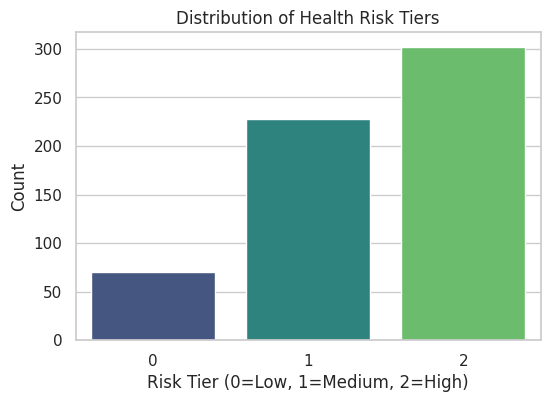

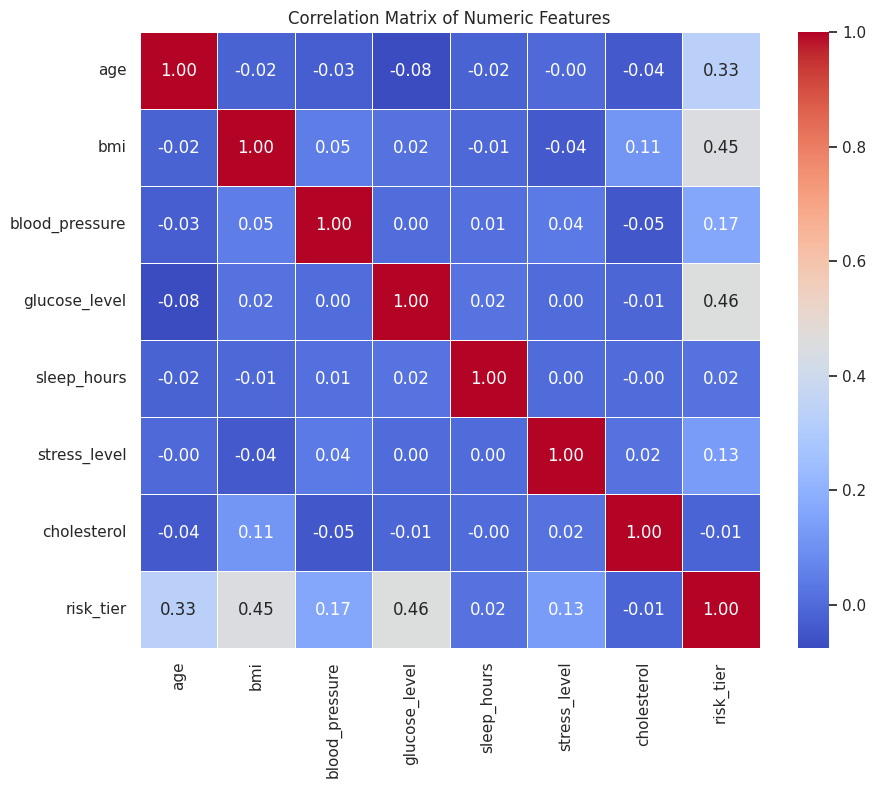

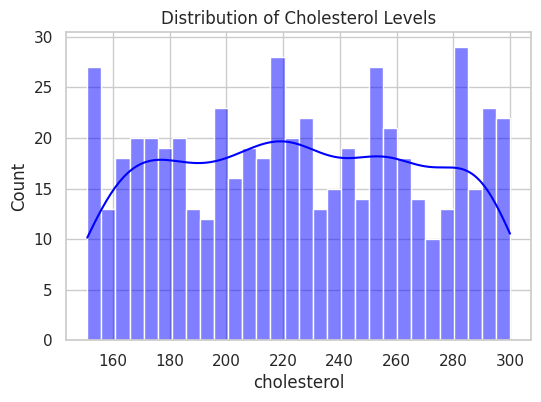

In [11]:
# Visual Check
# 1. Target variable distribution (Class Imbalance check)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='risk_tier', palette='viridis')
plt.title('Distribution of Health Risk Tiers')
plt.xlabel('Risk Tier (0=Low, 1=Medium, 2=High)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap (Numeric features only)
# We drop patient_id here temporarily just for the plot because it's non-informative noise
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).drop(columns=['patient_id'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

# 3. Cholesterol distribution (to help us decide how to impute)
plt.figure(figsize=(6, 4))
sns.histplot(df['cholesterol'], kde=True, color='blue', bins=30)
plt.title('Distribution of Cholesterol Levels')
plt.show()

### Step 4: Data Cleaning & Preprocessing

Okay, this is the most critical part. If garbage goes in, garbage comes out. Here is my plan of attack for cleaning this dataset and getting it ready for the machine learning models:

* **Remove Noise:** I'm dropping the `patient_id` column right away. It contains zero predictive value and keeping it might confuse the algorithms.
* **Encoding Categoricals:** Machine learning models need numbers, not words. I'll map the binary `family_history` to 0s and 1s. For `physical_activity`, I'll use an ordinal mapping (Low=0, Medium=1, High=2) since there is a natural logical order to those categories.
* **The Data Split (Crucial Step!):** I am doing a 70% Train, 15% Validation, and 15% Test split. I am using `stratify=y` to make sure each set gets a fair, representative mix of all three risk tiers. 
    * *Note:* I am splitting the data **before** doing any imputation or scaling. This is incredibly important to prevent "data leakage"—I can't let my training process peek at the validation or test distributions!
* **Imputation:** I'm using the median to fill in the missing cholesterol values because it's generally more robust to outliers than the mean. 
* **Scaling:** Finally, I'm scaling all the features using `StandardScaler`. This is an absolute requirement since my ultimate goal is to build an Artificial Neural Network (ANN), and neural networks are notoriously sensitive to unscaled data.

In [12]:
#Feature ENgineering

# --- A. Drop Non-Informative Columns ---
df_cleaned = df.drop(columns=['patient_id'])

# --- B. Encode Categorical Variables ---
# 'family_history' is binary, so we map Yes->1, No->0
df_cleaned['family_history'] = df_cleaned['family_history'].map({'Yes': 1, 'No': 0})

# 'physical_activity' is ordinal (has an inherent order), so we map Low->0, Medium->1, High->2
df_cleaned['physical_activity'] = df_cleaned['physical_activity'].map({'Low': 0, 'Medium': 1, 'High': 2})

# --- C. Separate Features (X) and Target (y) ---
X = df_cleaned.drop(columns=['risk_tier'])
y = df_cleaned['risk_tier']

# --- D. Train / Validation / Test Split ---
# First, split into Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

# Second, split Temp into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# --- E. Impute Missing Values (Cholesterol) ---
# We use the median because cholesterol distributions are often slightly skewed, 
# and median is robust to outliers. We fit ONLY on the training data!
imputer = SimpleImputer(strategy='median')

# We need to grab the column index or name to replace it properly
chol_idx = X_train.columns.get_loc('cholesterol')

X_train['cholesterol'] = imputer.fit_transform(X_train[['cholesterol']])
X_val['cholesterol'] = imputer.transform(X_val[['cholesterol']])
X_test['cholesterol'] = imputer.transform(X_test[['cholesterol']])

# --- F. Feature Scaling ---
# Neural Networks and distance-based algorithms require scaled data.
scaler = StandardScaler()

# Fit on training data, then transform train, val, and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrames for easier handling later (optional but good for tracking feature names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("\nPhase 1 Complete! Data is cleaned, imputed, encoded, and scaled.")

Training set size: 420 samples
Validation set size: 90 samples
Test set size: 90 samples

Phase 1 Complete! Data is cleaned, imputed, encoded, and scaled.
